In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 200          # number of fish
L = 10.0         # side length of the square box
v0 = 0.5         # speed
radius = 1.0     # how far a fish "sees" its neighbors
noise = 0.3      # noise strength (eta)
n_steps = 300    # number of timesteps
rng = np.random.default_rng(0)


In [3]:
pos = rng.uniform(0, L, size=(N, 2))
theta = rng.uniform(-np.pi, np.pi, size=N)
print(pos.shape, theta.shape)


(200, 2) (200,)


In [4]:
diff = pos[:, None, :] - pos[None, :, :]
diff -= L * np.round(diff / L)
dist = np.sqrt((diff ** 2).sum(axis=-1))
print(dist.shape)


(200, 200)


In [5]:
neighbor_mask = dist < radius
print(neighbor_mask.sum(axis=1).mean())


7.3


In [6]:
sin_sum = (np.sin(theta)[None, :] * neighbor_mask).sum(axis=1)
cos_sum = (np.cos(theta)[None, :] * neighbor_mask).sum(axis=1)
mean_theta = np.arctan2(sin_sum, cos_sum)


In [7]:
theta = mean_theta + noise * rng.uniform(-np.pi, np.pi, size=N)


In [8]:
pos = (pos + v0 * np.column_stack([np.cos(theta), np.sin(theta)])) % L


In [9]:
order = np.sqrt(np.cos(theta).sum() ** 2 + np.sin(theta).sum() ** 2) / N
print(order)


0.24253230008670318


In [10]:
def run_vicsek(N=200, L=10.0, v0=0.5, radius=1.0, noise=0.3,
               n_steps=300, seed=0):
    rng = np.random.default_rng(seed)
    pos = rng.uniform(0, L, size=(N, 2))
    theta = rng.uniform(-np.pi, np.pi, size=N)
    order_history = np.zeros(n_steps)

    for t in range(n_steps):
        diff = pos[:, None, :] - pos[None, :, :]
        diff -= L * np.round(diff / L)
        dist = np.sqrt((diff ** 2).sum(axis=-1))
        mask = dist < radius

        sin_sum = (np.sin(theta)[None, :] * mask).sum(axis=1)
        cos_sum = (np.cos(theta)[None, :] * mask).sum(axis=1)
        mean_theta = np.arctan2(sin_sum, cos_sum)

        theta = mean_theta + noise * rng.uniform(-np.pi, np.pi, size=N)
        pos = (pos + v0 * np.column_stack([np.cos(theta), np.sin(theta)])) % L

        order_history[t] = np.sqrt(np.cos(theta).sum() ** 2
                                   + np.sin(theta).sum() ** 2) / N

    return pos, theta, order_history


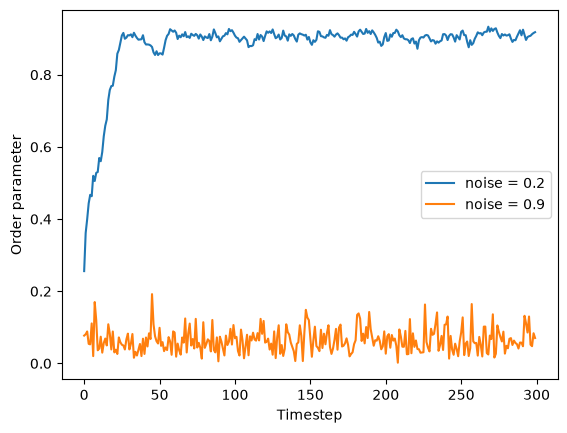

In [11]:
_, _, order_low = run_vicsek(noise=0.2)
_, _, order_high = run_vicsek(noise=0.9)

plt.plot(order_low, label="noise = 0.2")
plt.plot(order_high, label="noise = 0.9")
plt.xlabel("Timestep")
plt.ylabel("Order parameter")
plt.legend()
plt.show()


In [12]:
noise_levels = np.linspace(0.02, 1.0, 18)
final_order = []

for eta in noise_levels:
    _, _, order_history = run_vicsek(noise=eta, n_steps=250, seed=1)
    final_order.append(order_history[-50:].mean())

final_order = np.array(final_order)
print(np.round(final_order, 3))


[0.999 0.987 0.95  0.913 0.848 0.79  0.68  0.59  0.456 0.224 0.152 0.123
 0.091 0.088 0.071 0.071 0.065 0.054]


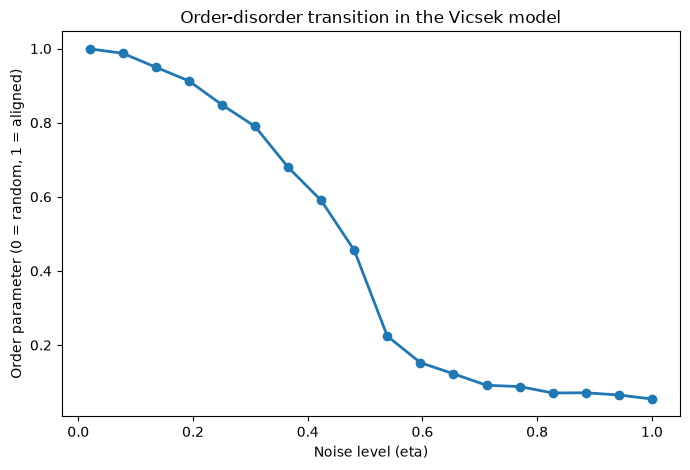

In [13]:
plt.figure(figsize=(7, 4.8))
plt.plot(noise_levels, final_order, marker="o", linewidth=2)
plt.xlabel("Noise level (eta)")
plt.ylabel("Order parameter (0 = random, 1 = aligned)")
plt.title("Order-disorder transition in the Vicsek model")
plt.tight_layout()
plt.savefig("fig1_phase_transition.png", dpi=150)
plt.show()


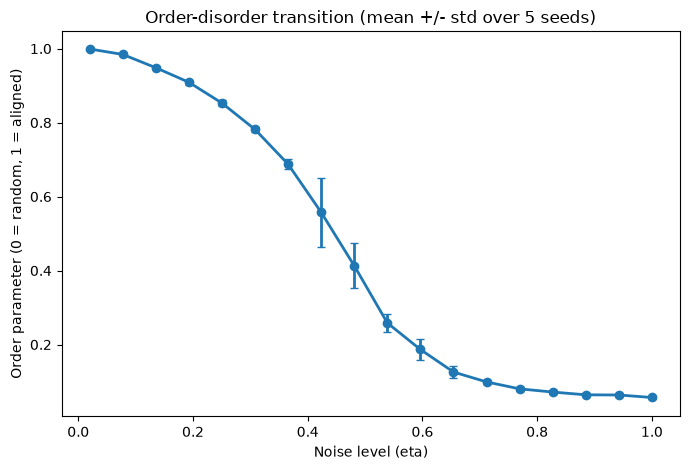

In [14]:
seeds = [1, 2, 3, 4, 5]
all_runs = []

for s in seeds:
    run = []
    for eta in noise_levels:
        _, _, oh = run_vicsek(noise=eta, n_steps=250, seed=s)
        run.append(oh[-50:].mean())
    all_runs.append(run)

all_runs = np.array(all_runs)
mean_order = all_runs.mean(axis=0)
std_order = all_runs.std(axis=0)

plt.figure(figsize=(7, 4.8))
plt.errorbar(noise_levels, mean_order, yerr=std_order,
             marker="o", linewidth=2, capsize=3)
plt.xlabel("Noise level (eta)")
plt.ylabel("Order parameter (0 = random, 1 = aligned)")
plt.title("Order-disorder transition (mean +/- std over 5 seeds)")
plt.tight_layout()
plt.savefig("fig1_phase_transition.png", dpi=150)
plt.show()


In [15]:
noise_low, noise_high = 0.15, 0.9

pos_low, theta_low, order_low = run_vicsek(noise=noise_low, n_steps=200, seed=2)
pos_high, theta_high, order_high = run_vicsek(noise=noise_high, n_steps=200, seed=2)

print(order_low[-50:].mean(), order_high[-50:].mean())


0.9366606641913637 0.06601548920423277


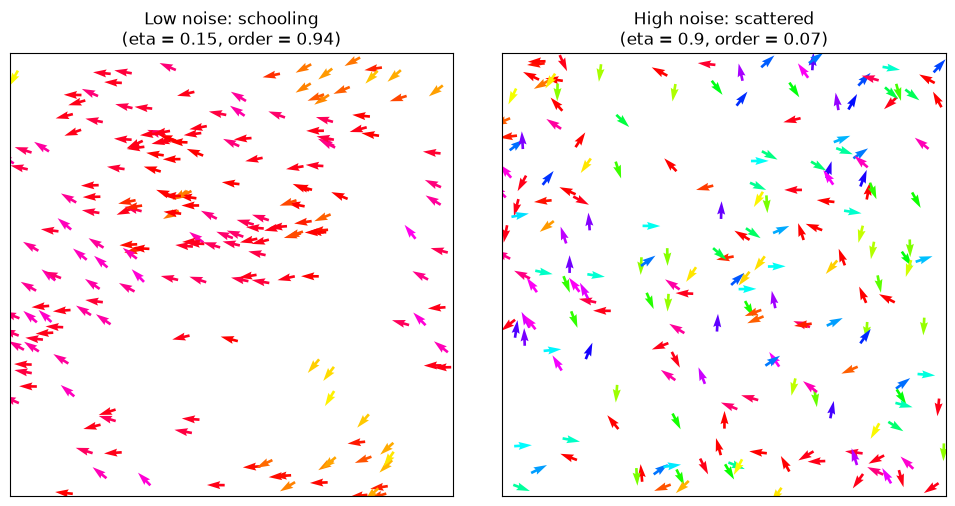

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, pos, theta, order, eta, label in [
    (axes[0], pos_low, theta_low, order_low, noise_low, "Low noise: schooling"),
    (axes[1], pos_high, theta_high, order_high, noise_high, "High noise: scattered"),
]:
    ax.quiver(pos[:, 0], pos[:, 1], np.cos(theta), np.sin(theta),
              theta, cmap="hsv", clim=(-np.pi, np.pi),
              scale=25, width=0.006)
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{label}\n(eta = {eta}, order = {order[-50:].mean():.2f})")

plt.tight_layout()
plt.savefig("fig2_snapshots.png", dpi=150)
plt.show()

In [17]:
ax.quiver(pos[:, 0], pos[:, 1], np.cos(theta), np.sin(theta),
          theta, cmap="hsv", clim=(-np.pi, np.pi),
          scale=25, width=0.006);

In [18]:
np.savetxt("phase_transition_results.csv",
           np.column_stack([noise_levels, final_order]),
           delimiter=",", header="noise_level,order_parameter", comments="")


In [19]:
np.savetxt("phase_transition_results.csv",
           np.column_stack([noise_levels, mean_order, std_order]),
           delimiter=",", header="noise_level,mean_order,std_order", comments="")
